In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib as mpl
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

from adjustText import adjust_text

### 1. Import all necessary datasets obtained from the material stock and GHG emissions assessment

In [2]:
material_stock_agg = pd.read_csv('material_stock_agg.csv',dtype={"kommunenum": str})
ms_emissions_agg = pd.read_csv('ms_emissions_agg.csv',dtype={"kommunenum": str})
manufacturing_emissions_agg = pd.read_csv('manufacturing_emissions_agg.csv',dtype={"kommunenum": str})
summary_df = pd.read_csv('summary_df.csv',dtype={"kommunenum": str})
total_heated_area_melted = pd.read_csv("total_heated_area_melted.csv", dtype={"kommunenum": str})

### 2. Import and work on population data

In [21]:
population_2024 = pd.read_excel(
    "/Users/dolgayamaria/Thesis/Practical Part/Data/01222_20250626-164638.xlsx",
    skiprows=3,
    header=0,
    nrows=360
)

# Rename the first column to 'raw'
population_2024 = population_2024.rename(columns={population_2024.columns[0]: 'raw'})

# Drop the unwanted “K-21-22…”, “K-23…” and “K-Rest…” rows
exclude = [
    'K-21-22 Svalbard and Jan Mayen',
    'K-23 Continental shelf',
    'K-Rest Divided municalities and unknown'
]
population_2024 = population_2024[~population_2024['raw'].isin(exclude)]

# Use regex to extract the 4-digit code and the municipality name in one go
# raw e.g. "K-3101 Halden"
population_2024[['kommunenum', 'kommunenav']] = population_2024['raw'] \
    .str.extract(r'K-(\d{4})\s+(.+)$')

# Drop the helper column
population_2024 = population_2024.drop(columns=['raw'])

# Rename the remaining data column to 'population'
population_2024 = population_2024.rename(columns={population_2024.columns[0]: 'population'})

# Reorder
population_2024 = population_2024[['kommunenum', 'kommunenav', 'population']]

### 3. Import datasets containing georeferenced data on municipalities and counties

In [22]:
counties_masks_2024 = gpd.read_file('/Users/dolgayamaria/Thesis/Practical Part/Data/ssb_counties_masks/Fylker 2024.shp')

counties_coast = gpd.read_file('/Users/dolgayamaria/Thesis/Practical Part/Data/Geopackage/Fylker.gpkg')
counties_coast = counties_coast.rename(columns={"nummer": "fylkesnumm"})
counties_coast = counties_coast.rename(columns={"navn": "fylkesnavn"})

municipalities_coast = gpd.read_file('/Users/dolgayamaria/Thesis/Practical Part/Data/Geopackage/Kommuner.gpkg')
municipalities_coast = municipalities_coast.rename(columns={"nummer": "kommunenum"})
municipalities_coast = municipalities_coast.rename(columns={"navn": "kommunenav"})
municipalities_coast["kommunenum"] = municipalities_coast["kommunenum"].astype(str).str.zfill(4)

### 4. Create and export charts and maps that will be used for the theoretical part pf the study

#### 4.1 Total material stock by material type

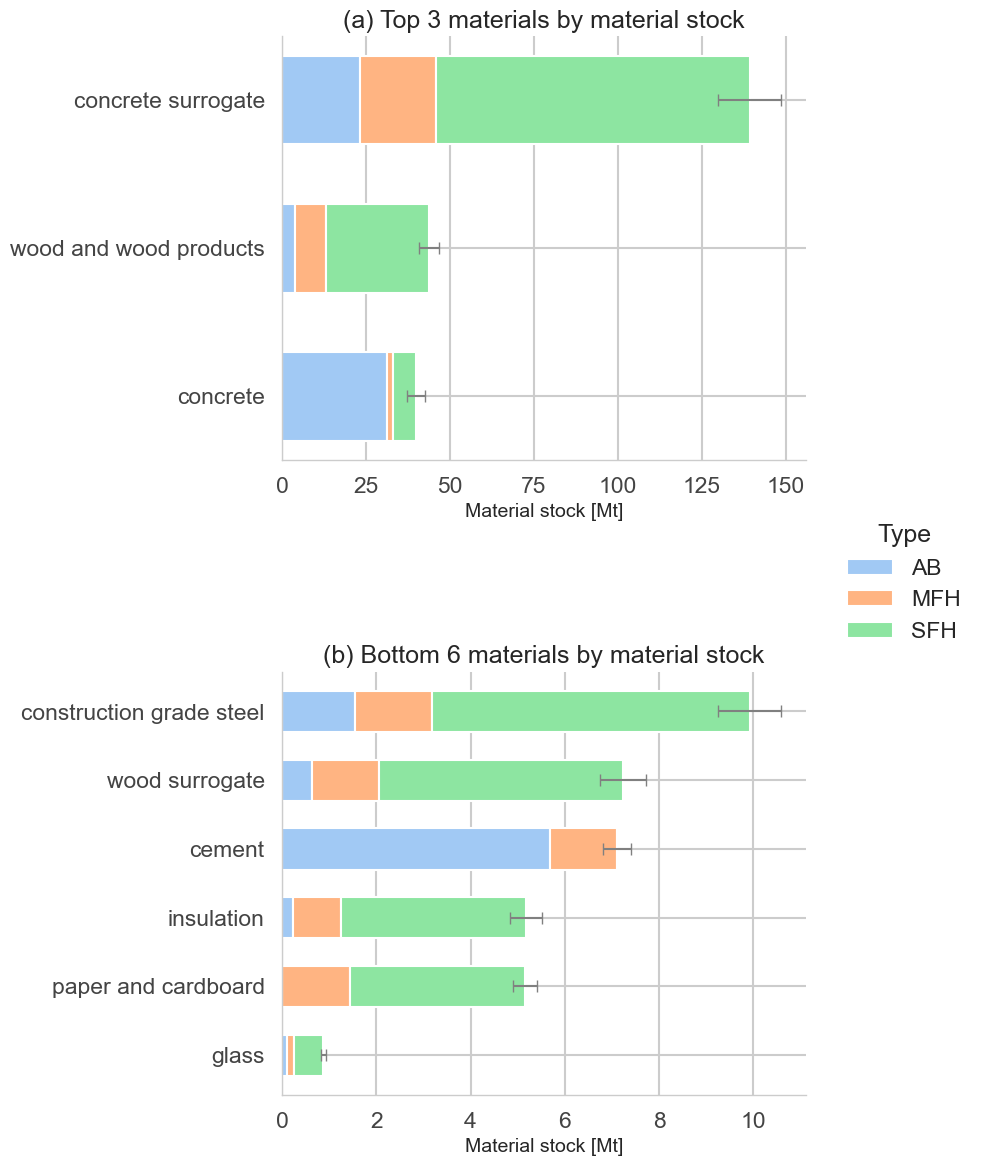

In [23]:
# 1) Style setup
sns.set(context="talk", style="whitegrid")
plt.rcParams["font.family"]  = "Arial"
plt.rcParams["axes.edgecolor"]  = "#CCCCCC"
plt.rcParams["axes.linewidth"]  = 1.0

# 2) Load / prepare data
df = material_stock_agg.copy()
df['kommunenum'] = df['kommunenum'].astype(str)

#   - remove TOTAL rows and NaNs
df = df[df.material != "TOTAL"].dropna(subset=["material_stock_mean", "material_stock_std_pct"])

#   - convert mean stock from kg to megatonnes
df["stock_mt"] = df["material_stock_mean"] / 1e9

#   - aggregate by material, type, cohort
agg = (
    df
    .groupby(["material", "type", "cohort"])
    .agg({
        "stock_mt": "sum",
        "material_stock_std_pct": "mean"
    })
    .reset_index()
)

# 3) Pivot for stacking: index=material, columns=type, values=stock_mt
pivot = (
    agg
    .pivot_table(
        index="material",
        columns="type",
        values="stock_mt",
        aggfunc="sum",
        fill_value=0
    )
)

# 4) Compute absolute error per material (total_mt * avg_std_pct)
totals = pivot.sum(axis=1)
avg_pct = (
    agg
    .groupby("material")["material_stock_std_pct"]
    .mean()
)
errors = totals * avg_pct / 100

# 5) Identify top-3 / bottom-6 by total stock
order   = totals.sort_values(ascending=False)
top3    = pivot.loc[order.index[:3]]
bottom6 = pivot.loc[order.index[-6:]]

# 6) Prepare colors & legend handles
types      = pivot.columns.tolist()
palette    = sns.color_palette("pastel", n_colors=len(types))
color_map  = dict(zip(types, palette))
legend_handles = [Patch(facecolor=color_map[t], label=t) for t in types]

# 7) Plotting function for each subset
def plot_subset(df_sub, ax, title):
    left = np.zeros(len(df_sub))
    for t in types:
        ax.barh(df_sub.index, df_sub[t],
                left=left, color=color_map[t], height=0.6)
        left += df_sub[t]
    # add error bars
    for idx, mat in enumerate(df_sub.index):
        ax.errorbar(
            x  = df_sub.loc[mat].sum(),
            y  = idx,
            xerr = errors[mat],
            fmt = "none",
            ecolor = "gray",
            capsize=4, lw=1.5
        )
    ax.set_title(title)
    ax.invert_yaxis()
    ax.set_xlabel("Material stock [Mt]", fontsize=14)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#CCCCCC")
    ax.tick_params(color="#888", labelcolor="#444")

# 8) Build the figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,12), sharex=False)

plot_subset(top3,    ax1, "(a) Top 3 materials by material stock")
plot_subset(bottom6, ax2, "(b) Bottom 6 materials by material stock")

# single legend on the side
fig.legend(handles=legend_handles,
           title="Type",
           loc="center right",
           frameon=False)

plt.tight_layout(rect=[0,0,0.85,1])
fig.subplots_adjust(hspace=0.5) 

'''fig.savefig(
    "material_stock_by_material.png",   
    dpi=300,                      
    bbox_inches="tight"           
)'''
plt.show()

#### 4.2 Total material stock by cohort for selected materials

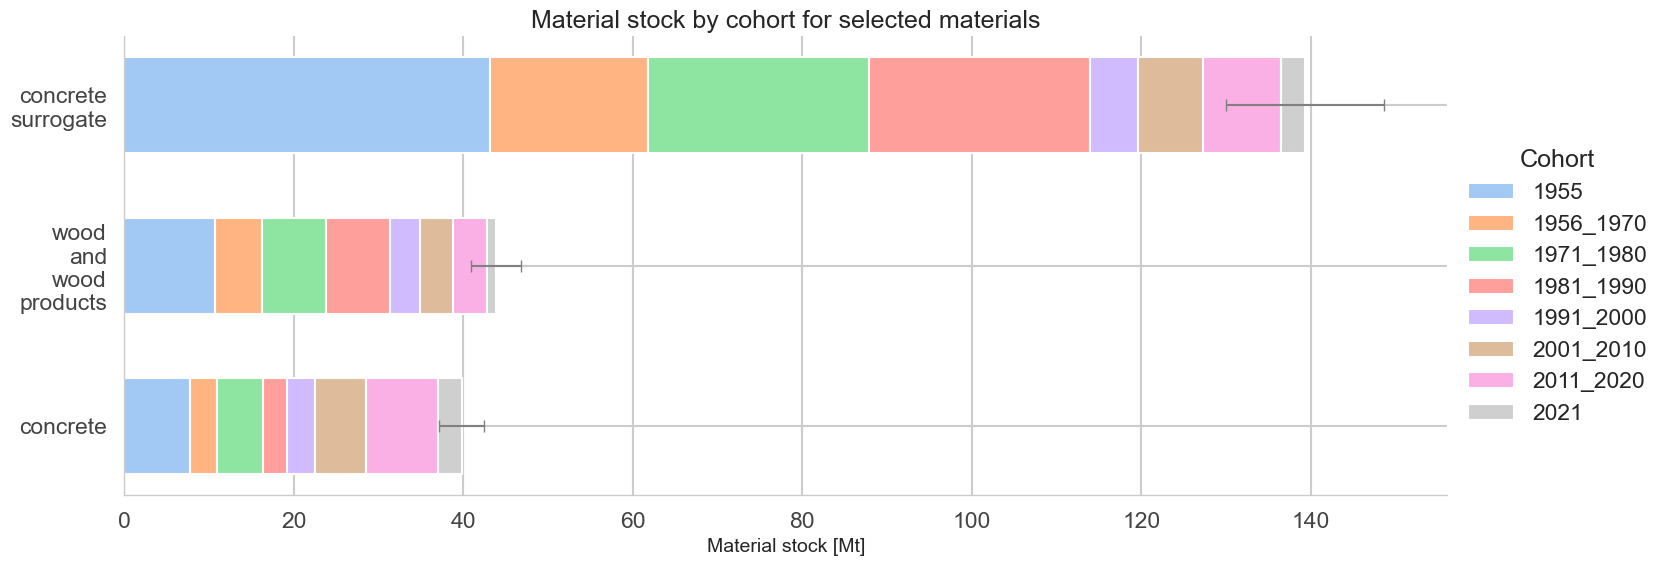

In [24]:
# 1) Style setup
sns.set(context="talk", style="whitegrid")
plt.rcParams["font.family"]  = "Arial"
plt.rcParams["axes.edgecolor"]  = "#CCCCCC"
plt.rcParams["axes.linewidth"]  = 1.0

# 2) Filter for selected materials and remove TOTAL, NaNs
materials_of_interest = ['concrete surrogate', 'wood and wood products', 'concrete']
df_sub = df[
    (df['material'].isin(materials_of_interest)) & 
    (df['material'] != "TOTAL")
].dropna(subset=["material_stock_mean", "material_stock_std_pct"]).copy()

# 3) Convert stock to megatonnes
df_sub["stock_mt"] = df_sub["material_stock_mean"] / 1e9

# 4) Aggregate by material and cohort (sum stock_mt)
agg_sub = (
    df_sub
    .groupby(["material", "cohort"])
    .agg({
        "stock_mt": "sum",
        "material_stock_std_pct": "mean"
    })
    .reset_index()
)

# 5) Pivot table for stacking: index=material, columns=cohort, values=stock_mt
pivot_sub = agg_sub.pivot_table(
    index="material",
    columns="cohort",
    values="stock_mt",
    aggfunc="sum",
    fill_value=0
)

# 6) Calculate errors by material (total_mt * avg std pct)
totals_sub = pivot_sub.sum(axis=1)
avg_pct_sub = agg_sub.groupby("material")["material_stock_std_pct"].mean()
errors_sub = totals_sub * avg_pct_sub / 100

# 7) Prepare colors & legend handles for cohorts
cohorts = pivot_sub.columns.tolist()
palette = sns.color_palette("pastel", n_colors=len(cohorts))
color_map = dict(zip(cohorts, palette))
legend_handles = [Patch(facecolor=color_map[c], label=str(c)) for c in cohorts]

# Sort materials by total stock descending
order = totals_sub.sort_values(ascending=False).index
pivot_sub = pivot_sub.loc[order]
errors_sub = errors_sub.loc[order]

pivot_sub.index = pivot_sub.index.str.replace(" ", "\n")
errors_sub.index = errors_sub.index.str.replace(" ", "\n")
totals_sub.index = totals_sub.index.str.replace(" ", "\n")

fig, ax = plt.subplots(figsize=(17, 6))

left = np.zeros(len(pivot_sub))
for cohort in cohorts:
    ax.barh(pivot_sub.index, pivot_sub[cohort],
            left=left, color=color_map[cohort], height=0.6, label=str(cohort))
    left += pivot_sub[cohort]

# Add error bars
for idx, material in enumerate(pivot_sub.index):
    ax.errorbar(
        x=totals_sub.loc[material],
        y=idx,
        xerr=errors_sub.loc[material],
        fmt="none",
        ecolor="gray",
        capsize=4, lw=1.5
    )

ax.set_xlabel("Material stock [Mt]", fontsize=14)
ax.set_title("Material stock by cohort for selected materials")
ax.invert_yaxis()  # keep highest total at top
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#CCCCCC")
ax.tick_params(color="#888", labelcolor="#444")

# Legend on right with no frame
ax.legend(title="Cohort", bbox_to_anchor=(1, 0.8), loc='upper left', frameon=False)

plt.tight_layout()
'''fig.savefig(
    "material_stock_by_cohort.png",   
    dpi=300,                      
    bbox_inches="tight"           
)'''
plt.show()

#### 4.3 Map of total material stock at municipal level in Norway

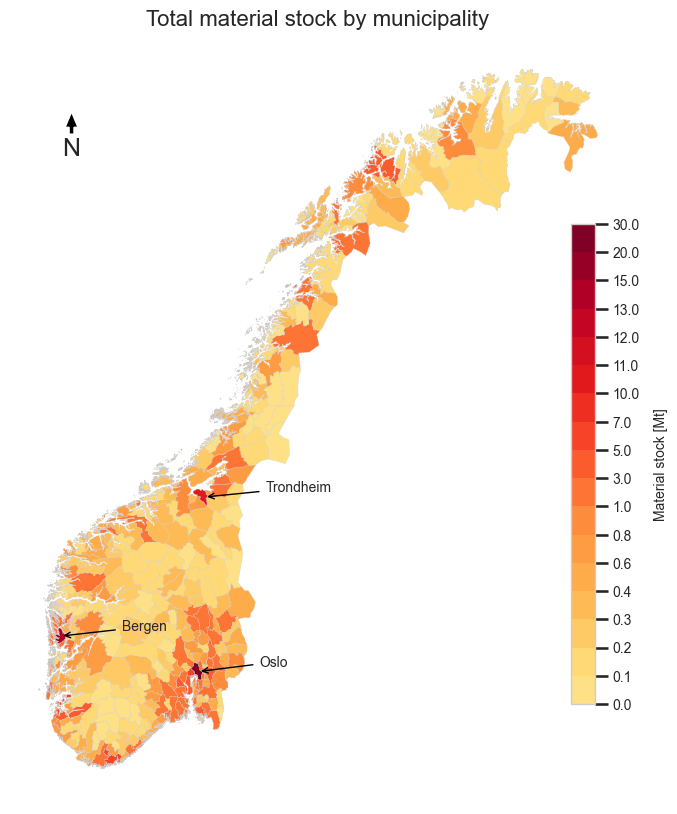

In [25]:
# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'

# 1. Ensure the key is a string
material_stock_agg['kommunenum'] = material_stock_agg['kommunenum'].astype(str)
municipalities_coast['kommunenum'] = municipalities_coast['kommunenum'].astype(str)

# 2. Filter only TOTAL
material_stock_agg_filter = material_stock_agg[material_stock_agg['material'] == 'TOTAL'].copy()

# 3. Aggregate mean stock per municipality (kg to Mt)
aggregated_df = material_stock_agg_filter.groupby('kommunenum', as_index=False)['material_stock_mean'].sum()
aggregated_df['material_stock_mean_Mt'] = aggregated_df['material_stock_mean'] / 1e9

# 4. Merge with GeoDataFrame
merged_gdf = municipalities_coast.merge(aggregated_df, on='kommunenum', how='left')

# 5. Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))


# Define custom bins and color ramp
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1, 3, 5, 7, 10, 11, 12, 13, 15, 20, 30]
colors = plt.cm.YlOrRd(np.linspace(0.2, 1, len(bins) - 1))
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N)

# Plot with custom color binning
cmap_plot = merged_gdf.plot(
    column='material_stock_mean_Mt',
    cmap=cmap,
    norm=norm,
    linewidth=0.2,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        'label': "Material stock [Mt]",
        'shrink': 0.5,
        'ticks': bins
    }
)

# Adjust legend (colorbar) label and tick font sizes
cbar = cmap_plot.get_figure().get_axes()[-1]  # Last axis is the colorbar
cbar.tick_params(labelsize=10)
cbar.set_ylabel("Material stock [Mt]", fontsize=10, labelpad=10)

# Move legend (colorbar) slightly to the left
cbar.set_position([0.7, 0.2, 0.02, 0.5])


ax.set_title('Total material stock by municipality', fontsize=16, loc='center')
ax.set_axis_off()

top3 = merged_gdf.nlargest(3, 'material_stock_mean_Mt')

for idx, row in top3.iterrows():
    name = row['kommunenav']
    point = row['geometry'].representative_point()
    x, y = point.x, point.y

    # Adjust these offsets as needed to move label into background space
    label_x = x + 130000   # 50 km east
    label_y = y + 20000   # 20 km north

    ax.annotate(
        name,
        xy=(x, y),  # Point on map
        xytext=(label_x, label_y),  # Label placed outside
        textcoords='data',
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color='black', lw=1),
        ha='left', va='center'
    )


# 6. Add North Arrow
def add_north_arrow(ax, x=0.1, y=0.9, size=18):
    ax.annotate('N', xy=(x, y), xytext=(x, y - 0.05),
                arrowprops=dict(facecolor='black', width=4, headwidth=10),
                ha='center', va='center',
                fontsize=size, xycoords=ax.transAxes)

add_north_arrow(ax)

# 7. Show or save
#plt.savefig('municipal_total_stock.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.4 Assess material stock per capita and plot a barchart showing comparison of the data obtained in this study and the published data (Rousseau et al. 2025)

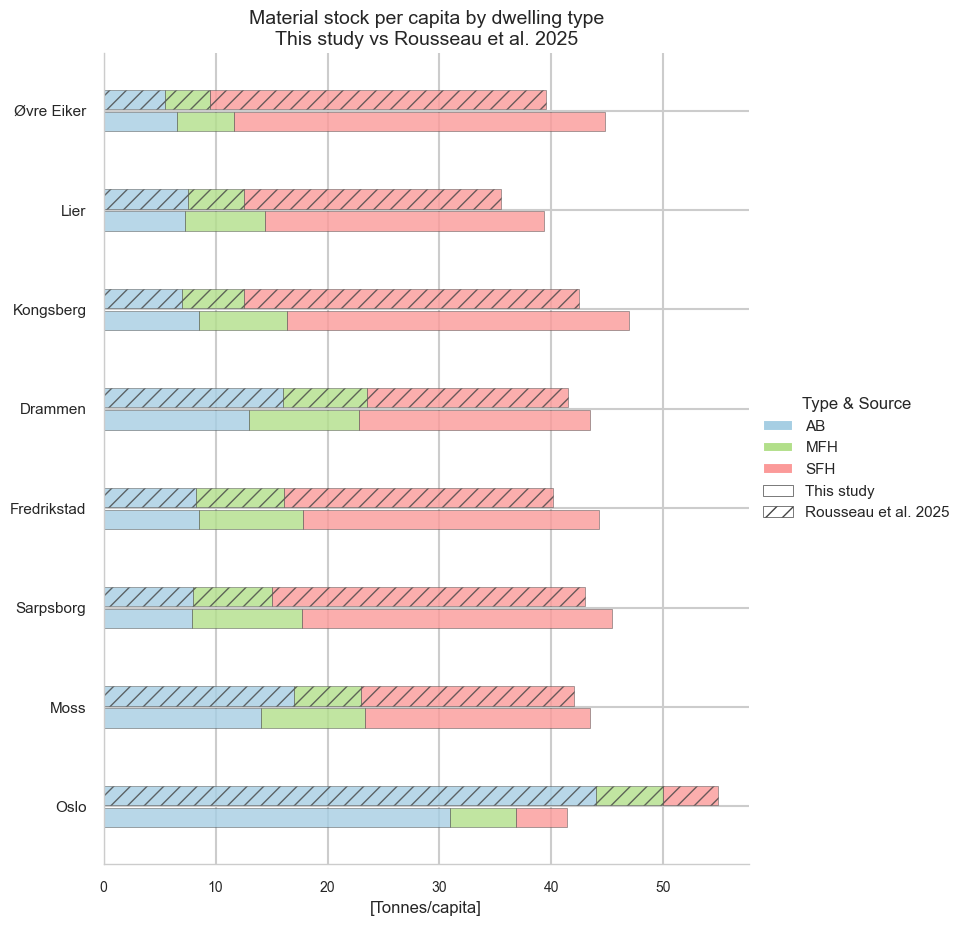

In [26]:
total_df = material_stock_agg[material_stock_agg['material'] == 'TOTAL'].copy()

# 2. Ensure kommunenum is string
total_df['kommunenum'] = total_df['kommunenum'].astype(str)
population_2024['kommunenum'] = population_2024['kommunenum'].astype(str)

# 3. Group by type and kommunenum to disaggregate
agg_df = (
    total_df
    .groupby(['type', 'kommunenum'], as_index=False)
    .agg({'material_stock_mean': 'sum'})
)

# 4. Merge with population data
merged_df = agg_df.merge(population_2024, on='kommunenum', how='left')

# 5. Filter for specific municipalities
selected_munis = ["0301", "3103", "3105", "3107", "3301", "3303", "3312", "3314"]
merged_df = merged_df[merged_df['kommunenum'].isin(selected_munis)].copy()

# 6. Calculate tonnes per capita
merged_df['t_per_capita'] = merged_df['material_stock_mean'] / 1000 / merged_df['population']


# 7. Define Rousseau data
ms_per_capita_Rousseau = {
    "Oslo": {"kommunenum": '0301', "AB": 44, "MFH": 6, "SFH": 4.9},
    "Sarpsborg": {"kommunenum": '3105', "AB": 8, "MFH": 7, "SFH": 28},
    "Kongsberg": {"kommunenum": '3303', "AB": 7, "MFH": 5.5, "SFH": 30},
    "Moss": {"kommunenum": '3103', "AB": 17, "MFH": 6, "SFH": 19},
    "Drammen": {"kommunenum": '3301', "AB": 16, "MFH": 7.5, "SFH": 18},
    "Fredrikstad": {"kommunenum": '3107', "AB": 8.2, "MFH": 7.9, "SFH": 24},
    "Øvre Eiker": {"kommunenum": '3314', "AB": 5.5, "MFH": 4, "SFH": 30},
    "Lier": {"kommunenum": '3312', "AB": 7.5, "MFH": 5, "SFH": 23}
}

# 8. Convert Rousseau to DataFrame
rows = []
for muni, vals in ms_per_capita_Rousseau.items():
    for t in ["AB", "MFH", "SFH"]:
        rows.append({
            "kommunenav": muni,
            "type": t,
            "t_per_capita": vals[t],
            "source": "Rousseau et al. 2025"
        })

rousseau_df = pd.DataFrame(rows)

# 9. Prepare your data (example: already merged)
# merged_df has columns: kommunenum, kommunenav, type, t_per_capita
this_study_df = merged_df.copy()
this_study_df["source"] = "This study"

# 10. Combine both datasets
combined_df = pd.concat([this_study_df[["kommunenav", "type", "t_per_capita", "source"]],
                         rousseau_df], ignore_index=True)



municipality_order = combined_df["kommunenav"].unique()[::-1]

type_order = ["AB", "MFH", "SFH"]
colors = {
    "AB": "#a6cee3",
    "MFH": "#b2df8a",
    "SFH": "#fb9a99"
}

# 11. Set up positions
bar_height = 0.35
pair_gap = 1.0  # space between municipality groups
bar_gap = 0.4   # small space between paired bars

positions = []
y_labels = []
y_ticks = []

current_y = 0

fig, ax = plt.subplots(figsize=(10, len(municipality_order) * 1.2))

for muni in municipality_order:
    muni_data = combined_df[combined_df["kommunenav"] == muni]

    # Plot both sources
    for j, source in enumerate(["Rousseau et al. 2025", "This study"]):
        row = muni_data[muni_data["source"] == source]
        if row.empty:
            continue
        row = row.set_index("type").reindex(type_order)["t_per_capita"].fillna(0)
        base = 0
        for t in type_order:
            ax.barh(
                current_y,
                row[t],
                left=base,
                color=colors[t],
                height=bar_height,
                edgecolor='#444444',
                hatch='//' if source == "Rousseau et al. 2025" else None,
                linewidth=0.4,
                alpha=0.8,
                label=f"{t} ({source})" if current_y == 0 else ""
            )
            base += row[t]

        # Store position
        positions.append(current_y)
        current_y += bar_gap

    # Label once for both bars
    y_ticks.append((positions[-2] + positions[-1]) / 2)
    y_labels.append(muni)

    current_y += pair_gap  # larger gap between municipalities

# 12. Axis formatting
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("[Tonnes/capita]", fontsize=12)
ax.set_title("Material stock per capita by dwelling type\nThis study vs Rousseau et al. 2025", fontsize=14)

# Define legend handles for types (colors)
type_handles = [
    Patch(facecolor=colors[t], label=t) for t in type_order
]

# Define legend handles for sources (styles)
source_handles = [
    Patch(facecolor='white', edgecolor='#444444', label="This study", linewidth=0.5),
    Patch(facecolor='white', edgecolor='#444444', hatch='//', label="Rousseau et al. 2025", linewidth=0.5)
]

# Combine both
legend_handles = type_handles + source_handles

# Add combined legend
ax.legend(
    handles=legend_handles,
    title="Type & Source",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
#plt.savefig('material_stock_verification.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.5 GHG emissions from material production by material type 

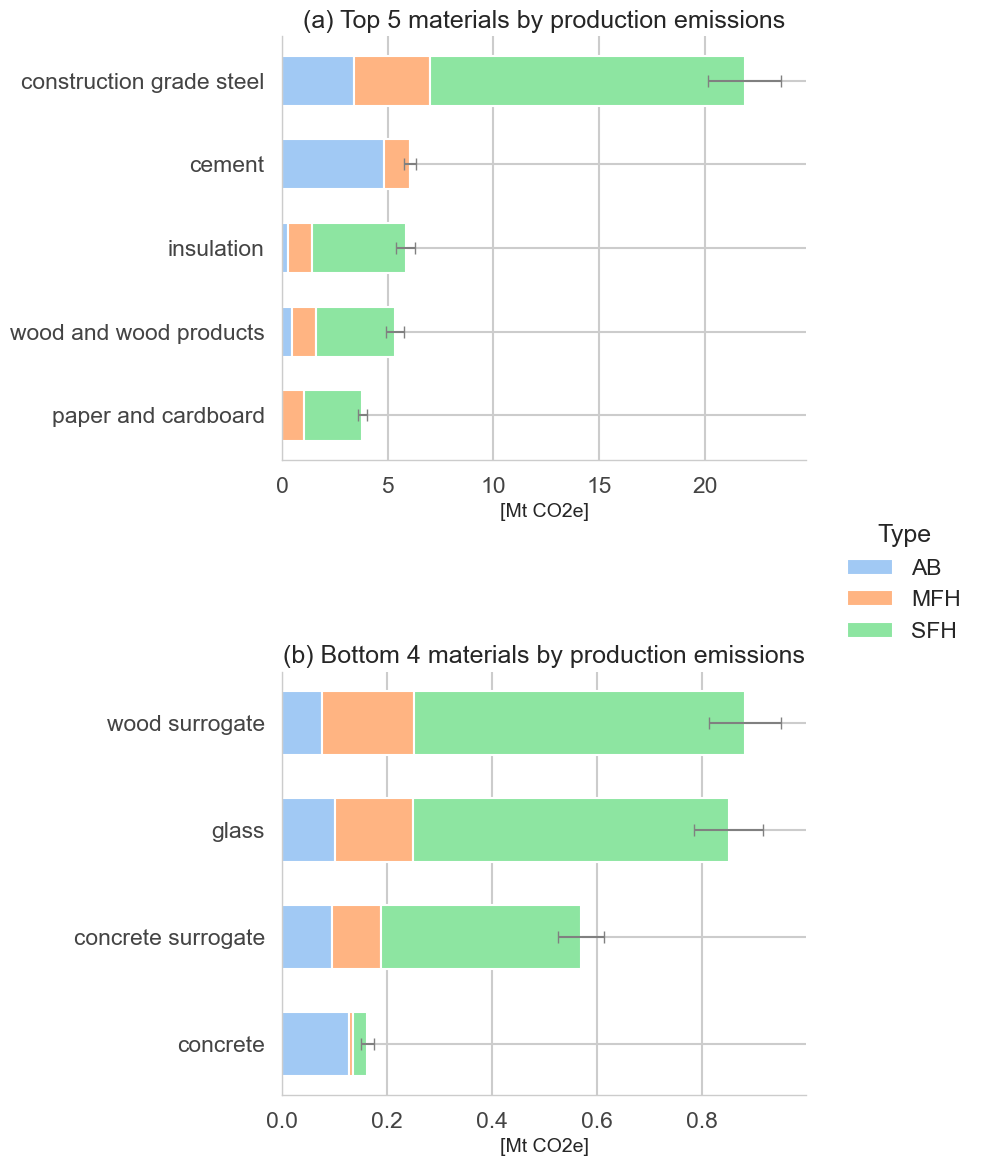

In [27]:
# 1) Style setup
sns.set(context="talk", style="whitegrid")
plt.rcParams["font.family"]  = "Arial"
plt.rcParams["axes.edgecolor"]  = "#CCCCCC"
plt.rcParams["axes.linewidth"]  = 1.0

# 2) Load / prepare data
df = ms_emissions_agg.copy()
df['kommunenum'] = df['kommunenum'].astype(str)

#   - remove TOTAL rows and NaNs
df = df[df.material != "TOTAL"].dropna(subset=["material_emissions_mean", "material_emissions_std_pct"])

#   - convert mean stock from kg to megatonnes
df["emissions_mt"] = df["material_emissions_mean"] / 1e9

#   - aggregate by material, type, cohort
agg = (
    df
    .groupby(["material", "type", "cohort"])
    .agg({
        "emissions_mt": "sum",
        "material_emissions_std_pct": "mean"
    })
    .reset_index()
)

# 3) Pivot for stacking: index=material, columns=type, values=stock_mt
pivot = (
    agg
    .pivot_table(
        index="material",
        columns="type",
        values="emissions_mt",
        aggfunc="sum",
        fill_value=0
    )
)

# 4) Compute absolute error per material (total_mt * avg_std_pct)
totals = pivot.sum(axis=1)
avg_pct = (
    agg
    .groupby("material")["material_emissions_std_pct"]
    .mean()
)
errors = totals * avg_pct / 100

# 5) Identify top-3 / bottom-6 by total stock
order   = totals.sort_values(ascending=False)
top3    = pivot.loc[order.index[:5]]
bottom6 = pivot.loc[order.index[-4:]]

# 6) Prepare colors & legend handles
types      = pivot.columns.tolist()
palette    = sns.color_palette("pastel", n_colors=len(types))
color_map  = dict(zip(types, palette))
legend_handles = [Patch(facecolor=color_map[t], label=t) for t in types]

# 7) Plotting function for each subset
def plot_subset(df_sub, ax, title):
    left = np.zeros(len(df_sub))
    for t in types:
        ax.barh(df_sub.index, df_sub[t],
                left=left, color=color_map[t], height=0.6)
        left += df_sub[t]
    # add error bars
    for idx, mat in enumerate(df_sub.index):
        ax.errorbar(
            x  = df_sub.loc[mat].sum(),
            y  = idx,
            xerr = errors[mat],
            fmt = "none",
            ecolor = "gray",
            capsize=4, lw=1.5
        )
    ax.set_title(title)
    ax.invert_yaxis()
    ax.set_xlabel("[Mt CO2e]", fontsize=14)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#CCCCCC")
    ax.tick_params(color="#888", labelcolor="#444")

# 8) Build the figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,12), sharex=False)

plot_subset(top3,    ax1, "(a) Top 5 materials by production emissions")
plot_subset(bottom6, ax2, "(b) Bottom 4 materials by production emissions")

# single legend on the side
fig.legend(handles=legend_handles,
           title="Type",
           loc="center right",
           frameon=False)

plt.tight_layout(rect=[0,0,0.85,1])
fig.subplots_adjust(hspace=0.5) 

'''fig.savefig(
    "material_emissions_by_material.png",   
    dpi=300,                      
    bbox_inches="tight"           
)'''
plt.show()

#### 4.6 GHG emissions from material production by cohort for selected materials

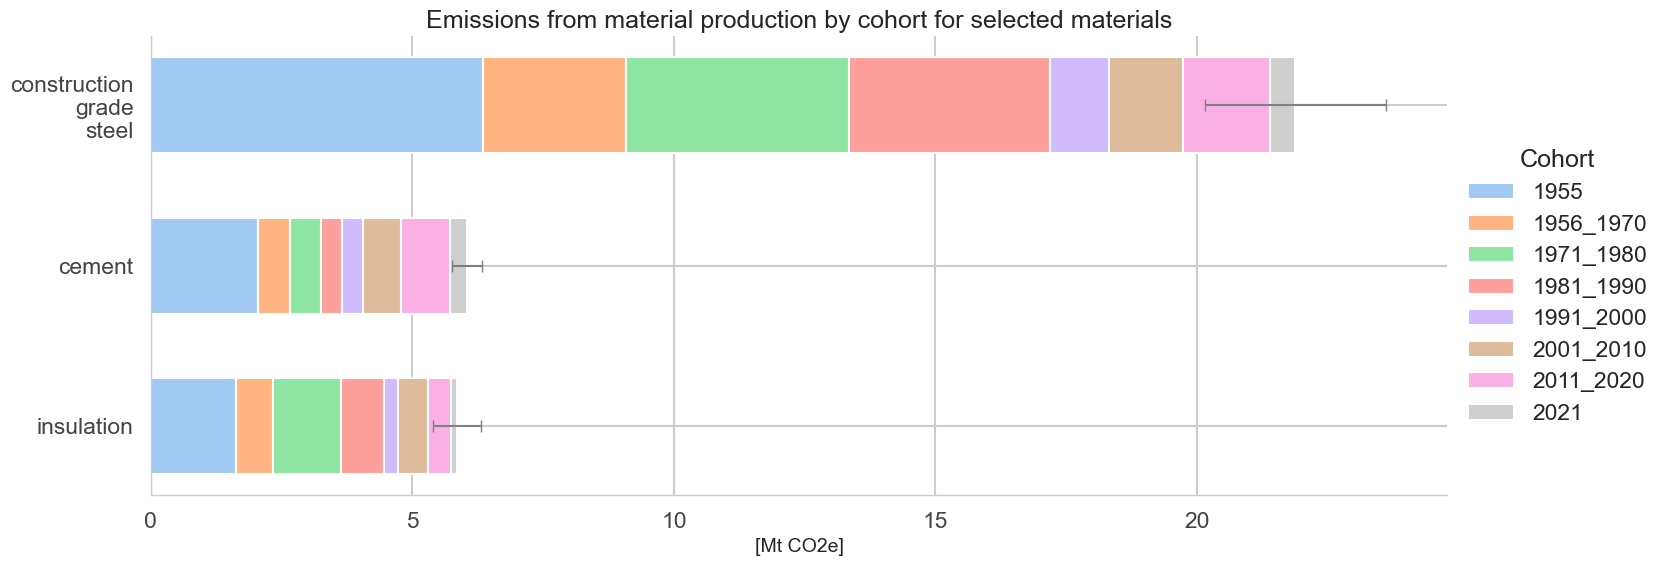

In [28]:
# 1) Style setup (as you had it)
sns.set(context="talk", style="whitegrid")
plt.rcParams["font.family"]  = "Arial"
plt.rcParams["axes.edgecolor"]  = "#CCCCCC"
plt.rcParams["axes.linewidth"]  = 1.0

# 2) Filter for selected materials and remove TOTAL, NaNs
materials_of_interest = ['construction grade steel', 'cement', 'insulation']
df_sub = df[
    (df['material'].isin(materials_of_interest)) & 
    (df['material'] != "TOTAL")
].dropna(subset=["material_emissions_mean", "material_emissions_std_pct"]).copy()

# 3) Convert stock to megatonnes
df_sub["emissions_mt"] = df_sub["material_emissions_mean"] / 1e9

# 4) Aggregate by material and cohort (sum stock_mt)
agg_sub = (
    df_sub
    .groupby(["material", "cohort"])
    .agg({
        "emissions_mt": "sum",
        "material_emissions_std_pct": "mean"
    })
    .reset_index()
)

# 5) Pivot table for stacking: index=material, columns=cohort, values=stock_mt
pivot_sub = agg_sub.pivot_table(
    index="material",
    columns="cohort",
    values="emissions_mt",
    aggfunc="sum",
    fill_value=0
)

# 6) Calculate errors by material (total_mt * avg std pct)
totals_sub = pivot_sub.sum(axis=1)
avg_pct_sub = agg_sub.groupby("material")["material_emissions_std_pct"].mean()
errors_sub = totals_sub * avg_pct_sub / 100

# 7) Prepare colors & legend handles for cohorts
cohorts = pivot_sub.columns.tolist()
palette = sns.color_palette("pastel", n_colors=len(cohorts))
color_map = dict(zip(cohorts, palette))
legend_handles = [Patch(facecolor=color_map[c], label=str(c)) for c in cohorts]

# Sort materials by total stock descending
order = totals_sub.sort_values(ascending=False).index
pivot_sub = pivot_sub.loc[order]
errors_sub = errors_sub.loc[order]

pivot_sub.index = pivot_sub.index.str.replace(" ", "\n")
errors_sub.index = errors_sub.index.str.replace(" ", "\n")
totals_sub.index = totals_sub.index.str.replace(" ", "\n")

fig, ax = plt.subplots(figsize=(17, 6))

left = np.zeros(len(pivot_sub))
for cohort in cohorts:
    ax.barh(pivot_sub.index, pivot_sub[cohort],
            left=left, color=color_map[cohort], height=0.6, label=str(cohort))
    left += pivot_sub[cohort]

# Add error bars
for idx, material in enumerate(pivot_sub.index):
    ax.errorbar(
        x=totals_sub.loc[material],
        y=idx,
        xerr=errors_sub.loc[material],
        fmt="none",
        ecolor="gray",
        capsize=4, lw=1.5
    )

ax.set_xlabel("[Mt CO2e]", fontsize=14)
ax.set_title("Emissions from material production by cohort for selected materials")
ax.invert_yaxis()  # keep highest total at top
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#CCCCCC")
ax.tick_params(color="#888", labelcolor="#444")

# Legend on right with no frame
ax.legend(title="Cohort", bbox_to_anchor=(1, 0.8), loc='upper left', frameon=False)

plt.tight_layout()
'''fig.savefig(
    "material_emissions_by_cohort.png",   
    dpi=300,                      
    bbox_inches="tight"           
)'''
plt.show()

#### 4.7 Manufacturing GHG emissions by building type and energy carrier

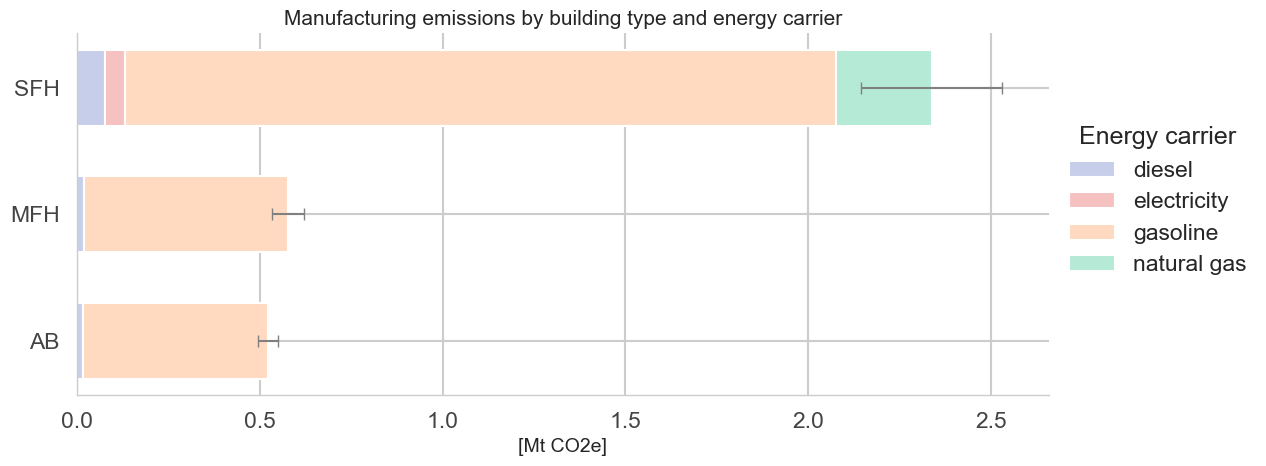

In [29]:
# 1. Plot style setup
sns.set(context="talk", style="whitegrid")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.linewidth"] = 1.0

# 2. Filter out TOTAL and NaNs
df = manufacturing_emissions_agg.copy()
df = df[df["energy_carrier"] != "TOTAL"].dropna(
    subset=["manufacturing_emissions_mean", "manufacturing_emissions_std_pct"]
)

# 3. Convert emissions to megatonnes
df["emissions_mt"] = df["manufacturing_emissions_mean"] / 1e9

# 4. Aggregate by dwelling type and energy carrier
agg_df = (
    df.groupby(["type", "energy_carrier"])
    .agg({
        "emissions_mt": "sum",
        "manufacturing_emissions_std_pct": "mean"
    })
    .reset_index()
)

# 5. Pivot for stacked bar plot
pivot = agg_df.pivot_table(
    index="type",
    columns="energy_carrier",
    values="emissions_mt",
    aggfunc="sum",
    fill_value=0
)

# 6. Calculate error bars (std deviation as % of total per type)
totals = pivot.sum(axis=1)
avg_std_pct = agg_df.groupby("type")["manufacturing_emissions_std_pct"].mean()
errors = totals * avg_std_pct / 100

# 7. Prepare pastel colors
energy_carriers = pivot.columns.tolist()
new_pastel_colors = [
    "#c7ceea",  # lavender
    "#f6c1c1",  # pink
    "#ffdac1",  # peach
    "#b5ead7",  # mint
    "#e2f0cb",  # light green
    "#d5aaff",  # pastel purple
]
color_map = dict(zip(energy_carriers, new_pastel_colors))
legend_handles = [Patch(facecolor=color_map[e], label=e) for e in energy_carriers]

# 8. Sort types by total emissions
order = totals.sort_values(ascending=False).index
pivot = pivot.loc[order]
errors = errors.loc[order]
totals = totals.loc[order]

# 9. Clean labels
pivot.index = pivot.index.str.replace(" ", "\n")
errors.index = errors.index.str.replace(" ", "\n")
totals.index = totals.index.str.replace(" ", "\n")

# 10. Plot
fig, ax = plt.subplots(figsize=(13, 5))
left = np.zeros(len(pivot))

for ec in energy_carriers:
    ax.barh(
        pivot.index,
        pivot[ec],
        left=left,
        color=color_map[ec],
        height=0.6,
        label=ec,
        edgecolor="#FFFFFF",
        linewidth=1.5
    )
    left += pivot[ec]

# Add error bars
for idx, t in enumerate(pivot.index):
    ax.errorbar(
        x=totals.loc[t],
        y=idx,
        xerr=errors.loc[t],
        fmt="none",
        ecolor="gray",
        capsize=4,
        lw=1.5
    )

# Formatting
ax.set_xlabel("[Mt CO2e]", fontsize=14)
ax.set_title("Manufacturing emissions by building type and energy carrier", fontsize=15)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")
ax.tick_params(color="#888", labelcolor="#444")

# Legend
ax.legend(title="Energy carrier", bbox_to_anchor=(1.0, 0.8), loc="upper left", frameon=False)

# Save and show
plt.tight_layout()
#plt.savefig("manufacturing_emissions_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4.8 Map of total GHG emissions at municipal level in Norway

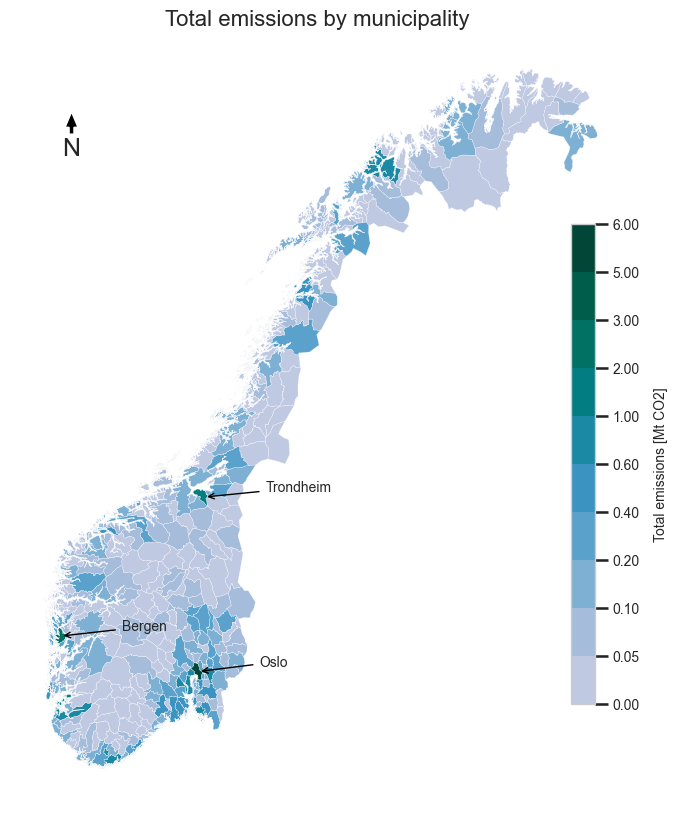

In [30]:
# Set global font to Arial and white-style borders
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["axes.edgecolor"]  = "#CCCCCC"
plt.rcParams["axes.linewidth"]  = 1.0

# Ensure keys are strings
summary_df['kommunenum'] = summary_df['kommunenum'].astype(str)
municipalities_coast['kommunenum'] = municipalities_coast['kommunenum'].astype(str)

# Aggregate total_mean (kg to Mt)
aggregated_df = summary_df.groupby('kommunenum', as_index=False)['total_mean'].sum()
aggregated_df['total_mean_Mt'] = aggregated_df['total_mean'] / 1e9

# Merge with GeoDataFrame
merged_gdf = municipalities_coast.merge(aggregated_df, on='kommunenum', how='left')

# Define manual bins & color map
bins = [0, 0.05, 0.1, 0.2, 0.4, 0.6, 1, 2, 3, 5, 6]
colors = plt.cm.PuBuGn(np.linspace(0.3, 1, len(bins) - 1))  
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

cmap_plot = merged_gdf.plot(
    column='total_mean_Mt',
    cmap=cmap,
    norm=norm,
    linewidth=0.2,
    edgecolor='white',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Total emissions [Mt]",
        'shrink': 0.5,
        'ticks': bins
    }
)

# Customize legend font sizes and layout
cbar = cmap_plot.get_figure().get_axes()[-1]
cbar.tick_params(labelsize=10)
cbar.set_ylabel("Total emissions [Mt CO2]", fontsize=10, labelpad=10)
cbar.set_position([0.7, 0.2, 0.02, 0.5]) 

# Map styling
ax.set_title('Total emissions by municipality', fontsize=16, loc='center')
ax.set_axis_off()

# Optional: annotate top 3 municipalities
top3 = merged_gdf.nlargest(3, 'total_mean_Mt')
for idx, row in top3.iterrows():
    name = row['kommunenav']
    point = row['geometry'].representative_point()
    x, y = point.x, point.y
    ax.annotate(
        name,
        xy=(x, y),
        xytext=(x + 130000, y + 20000),  
        textcoords='data',
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color='black', lw=1),
        ha='left', va='center'
    )

# Add north arrow
def add_north_arrow(ax, x=0.1, y=0.9, size=18):
    ax.annotate('N', xy=(x, y), xytext=(x, y - 0.05),
                arrowprops=dict(facecolor='black', width=4, headwidth=10),
                ha='center', va='center',
                fontsize=size, xycoords=ax.transAxes)

add_north_arrow(ax)

# Save or show
#plt.savefig('municipal_total_emissions_map.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.9 Top and bottom 10 municipalities by total per-capita emissions

/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_6875/2583910401.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_6875/2583910401.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_6875/2583910401.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
/var/folders/kn/87q7q5h140ldb97ht3jdcpr00000gn/T/ipykernel_6875/2583910401.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

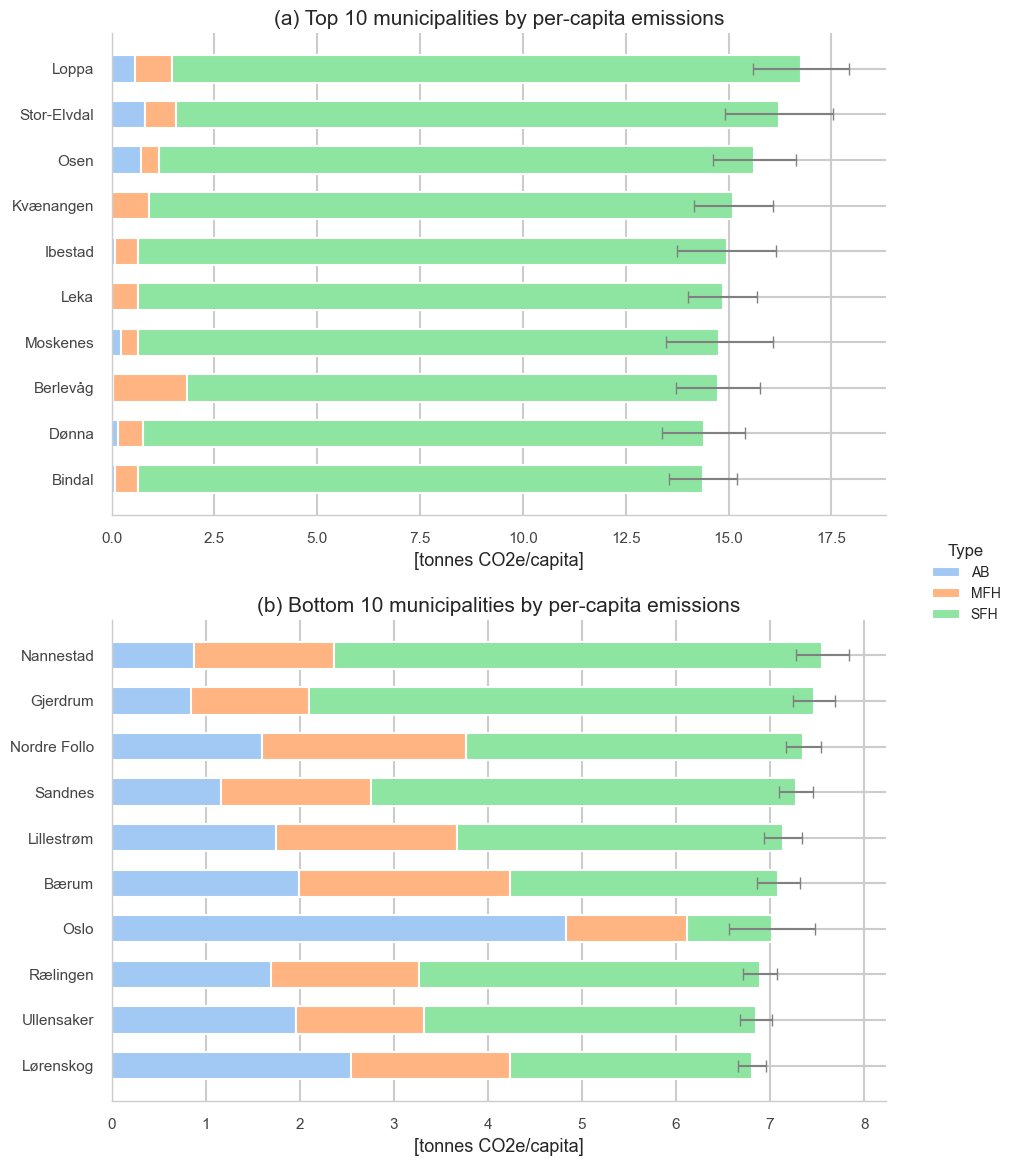

In [31]:
# 1) Normalize kommunenum in both dataframes.
population_2024['kommunenum'] = (
    population_2024['kommunenum']
    .astype(str)
    .str.zfill(4)
)
summary_df['kommunenum'] = (
    summary_df['kommunenum']
    .astype(str)
    .str.zfill(4)
)

# 2) Group summary_df by ['kommunenum', 'type'] and aggregate.
#    Sum total_mean (kg) and compute per-type std in kg.
aggregated = summary_df.groupby(['kommunenum','type']).apply(
    lambda g: pd.Series({
        'total_mean':   g['total_mean'].sum(),
        'total_std_kg': np.sqrt(np.sum((g['total_mean'] * g['total_std_pct'] / 100)**2))
    })
).reset_index()

# 3) Merge aggregated values with 2024 population and compute per-capita measures.
df = aggregated.merge(
    population_2024[['kommunenum','kommunenav','population']],
    on='kommunenum',
    how='left'
)
# Convert kg → tonnes
df["total_tonnes"] = df['total_mean'] / 1000
df["std_tonnes"]   = df["total_std_kg"] / 1000

# Compute per-capita
df['tonnes_per_capita']        = df["total_tonnes"] / df['population']
df["std_tonnes_per_capita"]    = df["std_tonnes"] / df["population"]

# 4) Compute overall per-capita for each municipality
overall = df.groupby(
    ['kommunenum','kommunenav','population'], as_index=False
).agg({
    'tonnes_per_capita':'sum'
}).rename(columns={'tonnes_per_capita':'overall_tonnes_per_capita'})

# Compute overall error via root-sum-square of per-type errors
overall_error = df.groupby(
    ['kommunenum','kommunenav','population'], as_index=False
).agg({
    'std_tonnes_per_capita': lambda x: np.sqrt(np.sum(x**2))
}).rename(columns={'std_tonnes_per_capita':'overall_std_tonnes_per_capita'})

overall = overall.merge(
    overall_error[['kommunenum','overall_std_tonnes_per_capita']],
    on='kommunenum', how='left'
)

# 5) Pick top and bottom municipalities by overall per-capita emissions.
top10    = overall.nlargest(10, 'overall_tonnes_per_capita')['kommunenum']
bottom10 = overall.nsmallest(10,'overall_tonnes_per_capita')['kommunenum']

order_top    = overall[overall['kommunenum'].isin(top10)]   \
                   .sort_values('overall_tonnes_per_capita', ascending=False)
order_bottom = overall[overall['kommunenum'].isin(bottom10)]\
                   .sort_values('overall_tonnes_per_capita', ascending=True)

# 6) Pivot the data for stacked bars.
def make_pivot(klist):
    sub   = df[df['kommunenum'].isin(klist)]
    pivot = sub.pivot(index='kommunenav', columns='type', values='tonnes_per_capita')
    return pivot[['AB','MFH','SFH']]

top_pivot    = make_pivot(top10)
bottom_pivot = make_pivot(bottom10)

# Reorder pivot tables using the overall ranking
top_order    = order_top   .set_index('kommunenav').loc[top_pivot.index]['overall_tonnes_per_capita'].index
bottom_order = order_bottom.set_index('kommunenav').loc[bottom_pivot.index]['overall_tonnes_per_capita'].index

top_pivot    = top_pivot   .reindex(top_order)
bottom_pivot = bottom_pivot.reindex(bottom_order)


# 7) Style and color setup
sns.set(context="talk", style="whitegrid")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.linewidth"] = 1.0

# 8) Use pastel color palette for building types
types = ['AB', 'MFH', 'SFH']
palette = sns.color_palette("pastel", n_colors=len(types))
colors = dict(zip(types, palette))

# 9) Reorder pivot tables by total per-capita emissions (descending)
top_pivot = top_pivot.loc[top_pivot.sum(axis=1).sort_values(ascending=False).index]
bottom_pivot = bottom_pivot.loc[bottom_pivot.sum(axis=1).sort_values(ascending=False).index]

# 10) Combined plot with shared legend on the right (centered)
def plot_combined_horizontal_per_capita(top_df, bottom_df, error_df, fname):
    fig, axes = plt.subplots(nrows=2, figsize=(10, 12), sharex=False)

    # For collecting handles/labels
    all_handles = []
    all_labels = []

    for ax, pivot_df, title in zip(
        axes,
        [top_df, bottom_df],
        ['(a) Top 10 municipalities by per-capita emissions',
         '(b) Bottom 10 municipalities by per-capita emissions']
    ):
        left = np.zeros(len(pivot_df))

        for btype in pivot_df.columns:
            bar = ax.barh(
                pivot_df.index,
                pivot_df[btype],
                left=left,
                color=colors[btype],
                label=btype,
                height=0.6
            )
            left += pivot_df[btype].fillna(0)

        # Add error bars
        for i, kommunenav in enumerate(pivot_df.index):
            row = error_df[error_df['kommunenav'] == kommunenav]
            if not row.empty:
                mean_val = row['overall_tonnes_per_capita'].values[0]
                err_val = row['overall_std_tonnes_per_capita'].values[0]
                ax.errorbar(
                    x=mean_val,
                    y=i,
                    xerr=err_val,
                    fmt='none',
                    ecolor='gray',
                    capsize=4,
                    linewidth=1.5
                )

        # Formatting
        ax.set_title(title, fontsize=15)
        ax.set_xlabel("[tonnes CO2e/capita]", fontsize=13)
        ax.set_ylabel("")
        ax.invert_yaxis()
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.tick_params(color="#888", labelcolor="#444")
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)

        handles, labels = ax.get_legend_handles_labels()
        all_handles = handles  # same for both axes
        all_labels = labels

    # Shared legend (center right)
    fig.legend(
        all_handles,
        all_labels,
        title='Type',
        title_fontsize=12,
        fontsize=10,
        loc='center right',
        bbox_to_anchor=(1.03, 0.5),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 0.93, 1])  # leave space on right for legend
    #plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

# 11) Call the function
plot_combined_horizontal_per_capita(
    top_df=top_pivot,
    bottom_df=bottom_pivot,
    error_df=overall,
    fname='top_bottom10_per_capita_emissions.png'
)

#### 4.10 Map of total GHG emissions per heated floor area at municipal level in Norway

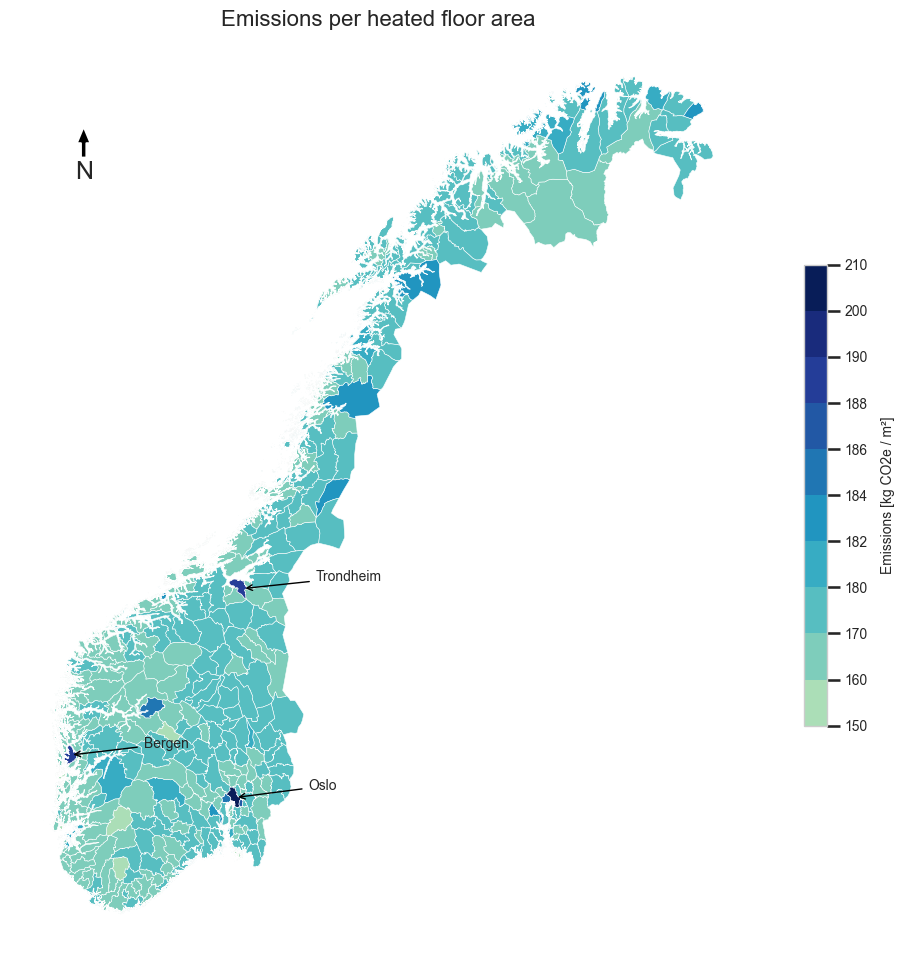

In [32]:
total_heated_area_melted = total_heated_area_melted.rename(columns={'Total Heated Area': 'total_heated_area'})

# --- STYLING SETUP ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.linewidth"] = 1.0

# --- Ensure kommunenum is normalized ---
summary_df['kommunenum'] = summary_df['kommunenum'].astype(str).str.zfill(4)
total_heated_area_melted['kommunenum'] = total_heated_area_melted['kommunenum'].astype(str).str.zfill(4)
municipalities_coast['kommunenum'] = municipalities_coast['kommunenum'].astype(str).str.zfill(4)

# --- 1) Add archetype key to summary_df ---
summary_df['archetype'] = summary_df['type'] + '_' + summary_df['cohort']

# --- 2) Merge with total heated area ---
total_heated_area_melted = total_heated_area_melted.rename(columns={'Archetype': 'archetype'})
merged_ha = summary_df.merge(
    total_heated_area_melted,
    on=['kommunenum', 'archetype'],
    how='left'
)

# --- 3) Plot function ---
def muni_map(subset_df, title, fname, use_mt=False):
    # Group and calculate emissions per m²
    muni = (
        subset_df
        .groupby('kommunenum', as_index=False)
        .agg(total_mean=('total_mean', 'sum'),
             total_area=('total_heated_area', 'sum'))
    )
    if use_mt:
        muni['emissions_metric'] = muni['total_mean'] / 1e6 / muni['total_area']  # Mt CO2-e per m²
        label = 'Emissions [Mt CO2e / m²]'
    else:
        muni['emissions_metric'] = muni['total_mean'] / muni['total_area']        # kg CO2-e per m²
        label = 'Emissions [kg CO2e / m²]'

    # Merge with GeoDataFrame
    gdf = municipalities_coast.merge(muni[['kommunenum', 'emissions_metric']], on='kommunenum', how='left')

    # Define colormap (YlGnBu as a good alternative pastel tone)
    bins = [150, 160, 170, 180, 182, 184, 186, 188, 190, 200, 210]
    colors = plt.cm.YlGnBu(np.linspace(0.3, 1, len(bins) - 1))
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bins, cmap.N)

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap_plot = gdf.plot(
        column='emissions_metric',
        cmap=cmap,
        norm=norm,
        linewidth=0.4,
        edgecolor='white',
        ax=ax,
        legend=True,
        legend_kwds={
            'label': label,
            'shrink': 0.5,
            'ticks': bins,
            'orientation': 'vertical'
        }
    )

    # Style legend
    cbar = cmap_plot.get_figure().get_axes()[-1]
    cbar.tick_params(labelsize=10)
    cbar.set_ylabel(label, fontsize=10, labelpad=10)
    cbar.set_position([0.7, 0.2, 0.02, 0.5])  # right-side center legend

    # Styling map
    ax.set_title(title, fontsize=16, loc='center')
    ax.set_axis_off()

    # Optional: annotate top 3 municipalities
    top3 = gdf.nlargest(3, 'emissions_metric')
    for idx, row in top3.iterrows():
        name = row['kommunenav']
        point = row['geometry'].representative_point()
        x, y = point.x, point.y
        ax.annotate(
            name,
            xy=(x, y),
            xytext=(x + 130000, y + 20000),
            textcoords='data',
            fontsize=10,
            arrowprops=dict(arrowstyle="->", color='black', lw=1),
            ha='left', va='center'
        )

    # North arrow
    def add_north_arrow(ax, x=0.1, y=0.9, size=18):
        ax.annotate('N', xy=(x, y), xytext=(x, y - 0.05),
                    arrowprops=dict(facecolor='black', width=4, headwidth=10),
                    ha='center', va='center',
                    fontsize=size, xycoords=ax.transAxes)

    add_north_arrow(ax)

    plt.tight_layout()
    #plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

# --- 4) Map for all cohorts ---
muni_map(
    merged_ha,
    title='Emissions per heated floor area',
    fname='emissions_per_m2_all_cohorts.png',
    use_mt=False  # Set to True if you want per m² in Mt
)